The objective of this notebook is to illustrate how the classification models can be used 

Let's first import the modules we need:

In [1]:
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pickle as pkl

We now need to load our data and the classification model. The data presented here came from peat porewater dissolved organic matter (DOM) analysed with a Bruker solariX ESI(–)-FT-ICR-MS system. The formula assignments was conducted using the CoreMS package. The model used in this demois the RBF-kernel SVM inclusive of PAHs, but the process is the same for the other models.

In [2]:
data_path = 'demo_data.csv'
data_df = pd.read_csv(data_path)
data_df.fillna(0,inplace=True)
data_df = data_df[data_df['Molecular Formula']!=0]

In [3]:
model_path = '..\\..\\mlacca_outputs\\models\\svm_rbf_with_pahs.pkl'
with open(model_path, "rb") as f:
    model = pkl.load(f)

Once we load our data, in this specific case we may notice that the formula assignment programme did not include a N/C column. This is easily fixed through pandas.

In [4]:
print(data_df.columns)

Index(['m/z', 'Calibrated m/z', 'Calculated m/z', 'Molecular Formula', 'C',
       'H', 'O', 'S', 'N', '13C', '34S', '18O'],
      dtype='object')


In [5]:
ratios_needed = ['O/C','H/C','N/C']

for ratio in ratios_needed:
    
    if ratio not in data_df.columns:
        
        elements = ratio.split('/')

        denominator = data_df[elements[1]]

        if elements[1] == 'C':
            denominator += data_df['13C']
        
        data_df[ratio] = data_df[elements[0]] / denominator

Now everything is ready for the classification model to predict compound classes!

In [6]:
predictions = model.predict(data_df[['O/C','H/C','N/C']].values)
predictions

array(['pah', 'lignin', 'lipid', ..., 'tannin', 'lignin', 'carbohydrate'],
      shape=(1954,), dtype=object)

The function ```predict_proba``` finds the predicted probability for each class.

In [7]:
predictions_probabilities = model.predict_proba(data_df[['O/C','H/C','N/C']].values)
predictions_probabilities

array([[2.37081017e-05, 7.89698004e-05, 1.18608459e-04, ...,
        9.22216246e-01, 5.14971497e-05, 6.95580336e-02],
       [1.02997117e-04, 3.78665003e-03, 9.10139047e-01, ...,
        7.35610770e-05, 9.14566432e-04, 5.32751409e-04],
       [3.30711449e-02, 1.60597999e-01, 2.20209952e-04, ...,
        6.86985622e-05, 6.75240169e-05, 8.00546848e-06],
       ...,
       [8.16310079e-04, 9.48058386e-05, 1.98024168e-01, ...,
        2.72614490e-04, 1.81432174e-04, 7.96273520e-01],
       [4.06274369e-05, 1.56238570e-04, 8.62209193e-01, ...,
        2.89579074e-04, 9.38582721e-05, 1.32916389e-01],
       [9.09653635e-02, 6.35515038e-01, 2.26974109e-03, ...,
        7.17878424e-05, 7.38320050e-05, 1.10963853e-05]], shape=(1954, 7))

The probability of the assigned class can thus be found. Both the assignments and their probabilities can then be added as columns in the dataframe.

In [8]:
max_probabilities = np.max(predictions_probabilities,axis=1)

data_df['compound_class'] = predictions
data_df['probability'] = max_probabilities
data_df

,m/z,Calibrated m/z,Calculated m/z,Molecular Formula,C,H,O,S,N,13C,34S,18O,O/C,H/C,N/C,compound_class,probability
0,645.219141,645.218553,645.218366,C45 H30 O3 N2,45.0,30.0,3.0,0.0,2.0,0.0,0.0,0.0,0.066667,0.666667,0.044444,pah,0.922216
1,619.203677,619.203125,619.203229,C30 H36 O14,30.0,36.0,14.0,0.0,0.0,0.0,0.0,0.0,0.466667,1.200000,0.000000,lignin,0.910139
2,617.358234,617.357685,617.357622,C28 H58 O12 S1,28.0,58.0,12.0,1.0,0.0,0.0,0.0,0.0,0.428571,2.071429,0.000000,lipid,0.805966
3,613.541768,613.541223,613.541264,C37 H74 O6,37.0,74.0,6.0,0.0,0.0,0.0,0.0,0.0,0.162162,2.000000,0.000000,lipid,0.904822
4,607.239979,607.239443,607.239615,C30 H40 O13,30.0,40.0,13.0,0.0,0.0,0.0,0.0,0.0,0.433333,1.333333,0.000000,lignin,0.905843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1949,213.076904,213.076827,213.076847,C10 H14 O5,10.0,14.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.400000,0.000000,lignin,0.894216
1950,211.061284,211.061210,211.061197,C10 H12 O5,10.0,12.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.200000,0.000000,lignin,0.909204
1951,211.024872,211.024798,211.024811,C9 H8 O6,9.0,8.0,6.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.888889,0.000000,tannin,0.796274
1952,209.045597,209.045525,209.045547,C10 H10 O5,10.0,10.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.000000,0.000000,lignin,0.862209


The results can be plotted on a 2D van Kreveln diagram.

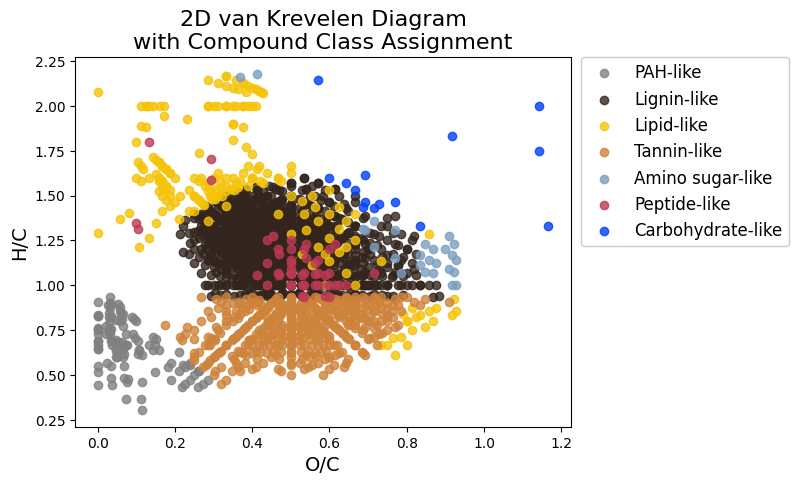

In [9]:
vk_region_colours = {
    'lipid': '#F5C308',
    'peptide': '#BD3A53',
    'carbohydrate': '#0040FF',
    'amino_sugar': '#7C9EBF',
    'lignin': '#33251E',
    'tannin': '#CE833B',
    'pah': "#808080",
}

fig, ax = plt.subplots()

for compound_class in data_df['compound_class'].unique():

    ax.scatter(data_df[data_df['compound_class']==compound_class]['O/C'],
               data_df[data_df['compound_class']==compound_class]['H/C'],
               c=vk_region_colours[compound_class],
               label=f'{compound_class.replace('_',' ').capitalize()}-like' if 'pah' not in compound_class else 'PAH-like',
               alpha=0.8)

ax.set_xlabel('O/C',fontsize=14)
ax.set_ylabel('H/C',fontsize=14)
ax.set_title('2D van Krevelen Diagram\nwith Compound Class Assignment',fontsize=16)
ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.savefig('2d_vK.png', dpi=600, facecolor='#fff', bbox_inches='tight')

Alternatively, the Plotly package can be used to draw 3D diagrams with N/C as an additional axis.

In [10]:
vizList = []
for compound_class in data_df['compound_class'].unique():

    globals()[f"D_{compound_class}"]=go.Scatter3d(

        x = data_df[data_df['compound_class'] == compound_class]['O/C'],
        y = data_df[data_df['compound_class'] == compound_class]['H/C'],
        z = data_df[data_df['compound_class'] == compound_class]['N/C'],

        name = f'{compound_class.replace('_',' ').capitalize()}-like' if 'pah' not in compound_class else 'PAH-like',

        hovertemplate = 'O/C: %{x} <br>' + \
                        'H/C: %{y} <br>' + \
                        'N/C: %{z} <br>',

        mode='markers',
        marker=dict(
            size=8,
            color=vk_region_colours[compound_class],           
            opacity=0.8,
            symbol='circle'
        )
    )

    vizList.append(globals()[f"D_{compound_class}"]) 

fig = go.Figure(data=vizList)

camera = dict(
        up=dict(x=0, y=0, z=1),
        center=dict(x=0, y=0, z=0),
        eye=dict(x=-1, y=-1.75, z=1.5)
    )

fig.update_layout(
    scene_camera=camera,
    autosize=True,
    template="plotly_white",
    scene={
        "xaxis_title":'O/C',
        "yaxis_title":'H/C',
        "zaxis_title":'N/C'
    },
    width=800, height=600,
    showlegend=True,
    legend_font_size = 14,
    title = '3D van Krevelen Diagram with Compound Class Assignment',
    title_font_size = 20
)

fig.show()

# 3D vK diagrams created with Plotly are saved as HTML files
fig.write_html('3d_vK.html')

One of the strengths of using a supervised classifier for compound class prediction is that we can have a measure of the confidence of the assignment. In the following cell we will visualise how the assignment confidence varies between different compound classes in this dataset.

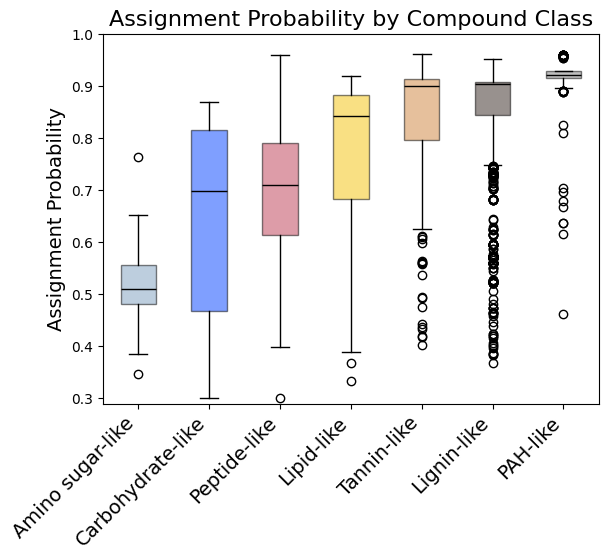

In [11]:
sorted_classes = data_df['compound_class'].unique()[np.argsort([np.median(data_df[data_df['compound_class']==x]['probability']) for x in data_df['compound_class'].unique()])]

probabilities_by_class = [data_df[data_df['compound_class']==compound_class]['probability'].to_list() for compound_class in sorted_classes]

fig, ax = plt.subplots()

bplot = ax.boxplot(probabilities_by_class,
                   medianprops = dict(color='k',ls='-'),
                   patch_artist = True,
                   showfliers = True)

for patch, compound_class in zip(bplot['boxes'],sorted_classes):
    patch.set_facecolor(vk_region_colours[compound_class])
    patch.set_alpha(0.5)

    
labels = [f'{x.replace('_',' ').capitalize()}-like' if 'pah' not in x else 'PAH-like' for x in sorted_classes]
ax.set_xticks(np.arange(1,len(labels)+1), labels, rotation=45, ha='right', fontsize=14)

ax.set_ylabel('Assignment Probability',fontsize=14)
ax.set_title('Assignment Probability by Compound Class',fontsize=16)

ax.set_ybound(np.min(data_df['probability'])-0.01,1)

Finally, we can save the dataframe to a new CSV file with the assignment data.

In [12]:
data_df.to_csv('demo_data--assigned.csv',index=None)

The analysis pipeline followed in this notebook can be easily turned into a function which takes the raw pandas dataframe and the prediction model as arguments and outputs a cleaned and assigned dataframe.

In [13]:
def compound_classification(data_df:pd.DataFrame,model:skl.calibration.CalibratedClassifierCV,
                            molec_form_column = 'Molecular Formula',
                            ratios_needed:list = ['O/C','H/C','N/C'],
                            isotope_pairs:list[list] = [['C','13C'],['H','2H'],['N','15N'],['O','18O'],['S','34S']]) -> pd.DataFrame:

    assert type(model) == skl.calibration.CalibratedClassifierCV, '`model` must be a `skl.calibration.CalibratedClassifierCV`'
    assert molec_form_column in data_df.columns, '`molec_form_column` must be the column of the `data_df` dataframe containing the assigned empirical formulae.'

    # copy the dataframe into another variable the function will be working on
    # substitute all NaNs with zeros and only select the rows with assigned empirical formulae
    assigned_df = data_df.copy()
    assigned_df.fillna(0,inplace=True)
    assigned_df = assigned_df[assigned_df[molec_form_column]!=0]

    # check that all necessary stoichiometric ratios are present in the df; add them in if not
    for ratio in ratios_needed:
        if ratio not in assigned_df.columns:
            elements = ratio.split('/')

            numerator = assigned_df[elements[0]]
            denominator = assigned_df[elements[1]]

            # account for isotopes
            for pair in isotope_pairs:
                if elements[0] == pair[0] and pair[1] in assigned_df.columns:
                    numerator += assigned_df[pair[1]]

                if elements[1] == pair[0] and pair[1] in assigned_df.columns:
                    denominator += assigned_df[pair[1]]
            
            assigned_df[ratio] = numerator / denominator
    
    # predict compound classes, their probabilities, and add them as new columns
    predictions = model.predict(assigned_df[ratios_needed].values)
    max_probabilities = np.max(model.predict_proba(assigned_df[ratios_needed].values),axis=1)
    assigned_df['compound_class'] = predictions
    assigned_df['probability'] = max_probabilities

    return assigned_df

In [14]:
data_df2 = pd.read_csv(data_path)
compound_classification(data_df2,model)

,m/z,Calibrated m/z,Calculated m/z,Molecular Formula,C,H,O,S,N,13C,34S,18O,O/C,H/C,N/C,compound_class,probability
0,645.219141,645.218553,645.218366,C45 H30 O3 N2,45.0,30.0,3.0,0.0,2.0,0.0,0.0,0.0,0.066667,0.666667,0.044444,pah,0.922216
1,619.203677,619.203125,619.203229,C30 H36 O14,30.0,36.0,14.0,0.0,0.0,0.0,0.0,0.0,0.466667,1.200000,0.000000,lignin,0.910139
2,617.358234,617.357685,617.357622,C28 H58 O12 S1,28.0,58.0,12.0,1.0,0.0,0.0,0.0,0.0,0.428571,2.071429,0.000000,lipid,0.805966
3,613.541768,613.541223,613.541264,C37 H74 O6,37.0,74.0,6.0,0.0,0.0,0.0,0.0,0.0,0.162162,2.000000,0.000000,lipid,0.904822
4,607.239979,607.239443,607.239615,C30 H40 O13,30.0,40.0,13.0,0.0,0.0,0.0,0.0,0.0,0.433333,1.333333,0.000000,lignin,0.905843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1949,213.076904,213.076827,213.076847,C10 H14 O5,10.0,14.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.400000,0.000000,lignin,0.894216
1950,211.061284,211.061210,211.061197,C10 H12 O5,10.0,12.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.200000,0.000000,lignin,0.909204
1951,211.024872,211.024798,211.024811,C9 H8 O6,9.0,8.0,6.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.888889,0.000000,tannin,0.796274
1952,209.045597,209.045525,209.045547,C10 H10 O5,10.0,10.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.000000,0.000000,lignin,0.862209


This function can be implemented in your compound class prediction pipeline seamlessly.